<center>
<img src="https://upload.wikimedia.org/wikipedia/fr/thumb/1/1d/Logo_T%C3%A9l%C3%A9com_SudParis.svg/960px-Logo_T%C3%A9l%C3%A9com_SudParis.svg.png" width="10%" />
</center>

<center> <h2>NET 4103/7431 Homework
Network science and Graph Learning </h2> </center>

<center> <h3> Rozi Harutyunyan (rozi.harutyunyan@telecom-sudparis.eu) </h3> </center>

### Question 4: Link Prediction with the Facebook100 Dataset

In [12]:

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Pour les classes abstraites
from abc import ABC, abstractmethod

# Pour le GNN (Q4e)
import torch
import torch.nn as nn
import torch.nn.functional as F
warnings.filterwarnings('ignore')
 
plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = Path('../data/facebook100')
RESULTS_PATH = Path('../results/figures')
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
 

In [13]:
# 1. Question 4b Link prediction classes
class LinkPrediction(ABC):
    def __init__(self, graph):
        """
        Constructor
        Parameters
        ----------
        graph : Networkx graph
        """
        self.graph = graph
        self.N = len(graph)
 
    def neighbors(self, v):
        """
        Return the neighbors list of a node
        Parameters
        ----------
        v: int  node id
        Return
        ------
        neighbors_list : python list
        """
        return list(self.graph.neighbors(v))
 
    @abstractmethod
    def fit(self):
        raise NotImplementedError("Fit must be implemented")
 
 
class CommonNeighbors(LinkPrediction):
    """
    Common Neighbors: score(u,v) = |N(u) ∩ N(v)|
    The more common neighbors two nodes share, the more likely they are to form a link.
    """
    def __init__(self, graph):
        super(CommonNeighbors, self).__init__(graph)
 
    def fit(self):
        scores = {}
        nodes = list(self.graph.nodes())
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                u, v = nodes[i], nodes[j]
                if not self.graph.has_edge(u, v):
                    # |N(u) ∩ N(v)|
                    common = len(set(self.neighbors(u)) & set(self.neighbors(v)))
                    scores[(u, v)] = common
        return scores
 
 
class Jaccard(LinkPrediction):
    """
    Jaccard Coefficient: score(u,v) = |N(u) ∩ N(v)| / |N(u) ∪ N(v)|
    Normalizes common neighbors by total neighbors, reducing bias toward high-degree nodes.
    """
    def __init__(self, graph):
        super(Jaccard, self).__init__(graph)
 
    def fit(self):
        scores = {}
        nodes = list(self.graph.nodes())
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                u, v = nodes[i], nodes[j]
                if not self.graph.has_edge(u, v):
                    nu = set(self.neighbors(u))
                    nv = set(self.neighbors(v))
                    intersection = len(nu & nv)
                    union = len(nu | nv)
                    scores[(u, v)] = intersection / union if union > 0 else 0.0
        return scores
 
 
class AdamicAdar(LinkPrediction):
    """
    Adamic/Adar Index: score(u,v) = Σ_{w ∈ N(u)∩N(v)} 1 / log(|N(w)|)
    Weights common neighbors by inverse log of their degree.
    Rare common neighbors contribute more than high-degree hubs.
    """
    def __init__(self, graph):
        super(AdamicAdar, self).__init__(graph)
 
    def fit(self):
        scores = {}
        nodes = list(self.graph.nodes())
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                u, v = nodes[i], nodes[j]
                if not self.graph.has_edge(u, v):
                    common_neighbors = set(self.neighbors(u)) & set(self.neighbors(v))
                    score = 0.0
                    for w in common_neighbors:
                        deg_w = len(self.neighbors(w))
                        if deg_w > 1:  # log(1) = 0, avoid division by zero
                            score += 1.0 / np.log(deg_w)
                    scores[(u, v)] = score
        return scores

In [14]:
#2. Question 4c Evaluating a link predictor
def load_network(filename):
    """Load network and extract LCC"""
    G = nx.read_gml(DATA_PATH / filename)
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()
 
 
def remove_edges(G, fraction):
    """
    Randomly remove a fraction f of edges from graph G.
    Returns: (G_modified, removed_edges)
    """
    edges = list(G.edges())
    n_remove = int(len(edges) * fraction)
    removed_edges = random.sample(edges, n_remove)
 
    G_modified = G.copy()
    G_modified.remove_edges_from(removed_edges)
    return G_modified, set(map(frozenset, removed_edges))
 
 
def evaluate_predictor(predictor_class, G_train, removed_edges, k_values):
    """
    Evaluate a link predictor:
    - Fit on G_train (graph with edges removed)
    - Rank predicted edges by score
    - Compute top@k, precision@k, recall@k for each k
    """
    predictor = predictor_class(G_train)
    scores = predictor.fit()
 
    # Sort by score descending
    sorted_pairs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
 
    results = {}
    for k in k_values:
        top_k_pairs = sorted_pairs[:k]
        predicted_set = set(frozenset(pair) for pair, _ in top_k_pairs)
 
        # Intersection with removed edges
        true_positives = len(removed_edges & predicted_set)
        false_positives = k - true_positives
        false_negatives = len(removed_edges) - true_positives
 
        top_at_k = true_positives / k if k > 0 else 0
        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
 
        results[k] = {
            'top@k': top_at_k,
            'precision@k': precision,
            'recall@k': recall,
            'true_positives': true_positives
        }
    return results
 


In [10]:
#Question 4d run evaluation on selected graphs 
# We use Caltech (small, fast to compute full |V|×|V| pairs)
print("Loading Caltech network...")
G_caltech = load_network('Caltech36.gml')
print(f"  → Caltech LCC: {G_caltech.number_of_nodes()} nodes, {G_caltech.number_of_edges()} edges")
 
# For MIT and JohnsHopkins, we use a subgraph for speed (full |V|x|V| is very large)
print("Loading MIT network...")
G_mit_full = load_network('MIT8.gml')
# Sample a subgraph of 500 nodes for tractability
mit_nodes = random.sample(list(G_mit_full.nodes()), min(500, G_mit_full.number_of_nodes()))
G_mit = G_mit_full.subgraph(mit_nodes).copy()
largest_cc_mit = max(nx.connected_components(G_mit), key=len)
G_mit = G_mit.subgraph(largest_cc_mit).copy()
print(f"  → MIT subgraph: {G_mit.number_of_nodes()} nodes, {G_mit.number_of_edges()} edges")
 
print("Loading Johns Hopkins network...")
G_jh_full = load_network('Johns Hopkins55.gml')
jh_nodes = random.sample(list(G_jh_full.nodes()), min(500, G_jh_full.number_of_nodes()))
G_jh = G_jh_full.subgraph(jh_nodes).copy()
largest_cc_jh = max(nx.connected_components(G_jh), key=len)
G_jh = G_jh.subgraph(largest_cc_jh).copy()
print(f"  → Johns Hopkins subgraph: {G_jh.number_of_nodes()} nodes, {G_jh.number_of_edges()} edges")
 
# Parameters
fractions = [0.05, 0.1, 0.15, 0.2]
k_values = [50, 100, 200, 300, 400]
predictors = {
    'CommonNeighbors': CommonNeighbors,
    'Jaccard': Jaccard,
    'AdamicAdar': AdamicAdar
}
 
networks_eval = {
    'Caltech': G_caltech,
    'MIT (500-node sample)': G_mit,
    'JohnsHopkins (500-node sample)': G_jh
}
 
# ============================================================================
# Run evaluation and collect results
# ============================================================================
 
print("\n" + "="*70)
print("LINK PREDICTION EVALUATION")
print("="*70)
 
# Store results for plotting: results[network][predictor][fraction] = {k: metrics}
all_results = {net: {pred: {} for pred in predictors} for net in networks_eval}
 
for net_name, G in networks_eval.items():
    print(f"\n{'='*50}")
    print(f"Network: {net_name}")
    print(f"{'='*50}")
 
    for f in fractions:
        print(f"\n  Fraction removed: f={f}")
        G_train, removed_edges = remove_edges(G, f)
        print(f"    Removed {len(removed_edges)} edges")
 
        for pred_name, pred_class in predictors.items():
            print(f"    Running {pred_name}...", end=' ')
            try:
                results = evaluate_predictor(pred_class, G_train, removed_edges, k_values)
                all_results[net_name][pred_name][f] = results
                top50 = results[50]['top@k']
                print(f"top@50={top50:.3f}")
            except Exception as e:
                print(f"ERROR: {e}")

Loading Caltech network...
  → Caltech LCC: 762 nodes, 16651 edges
Loading MIT network...
  → MIT subgraph: 414 nodes, 1437 edges
Loading Johns Hopkins network...
  → Johns Hopkins subgraph: 426 nodes, 1738 edges

LINK PREDICTION EVALUATION

Network: Caltech

  Fraction removed: f=0.05
    Removed 832 edges
    Running CommonNeighbors... top@50=0.420
    Running Jaccard... top@50=0.300
    Running AdamicAdar... top@50=0.380

  Fraction removed: f=0.1
    Removed 1665 edges
    Running CommonNeighbors... top@50=0.620
    Running Jaccard... top@50=0.500
    Running AdamicAdar... top@50=0.680

  Fraction removed: f=0.15
    Removed 2497 edges
    Running CommonNeighbors... top@50=0.740
    Running Jaccard... top@50=0.500
    Running AdamicAdar... top@50=0.760

  Fraction removed: f=0.2
    Removed 3330 edges
    Running CommonNeighbors... top@50=0.780
    Running Jaccard... top@50=0.520
    Running AdamicAdar... top@50=0.760

Network: MIT (500-node sample)

  Fraction removed: f=0.05
    


Generating evaluation plots...


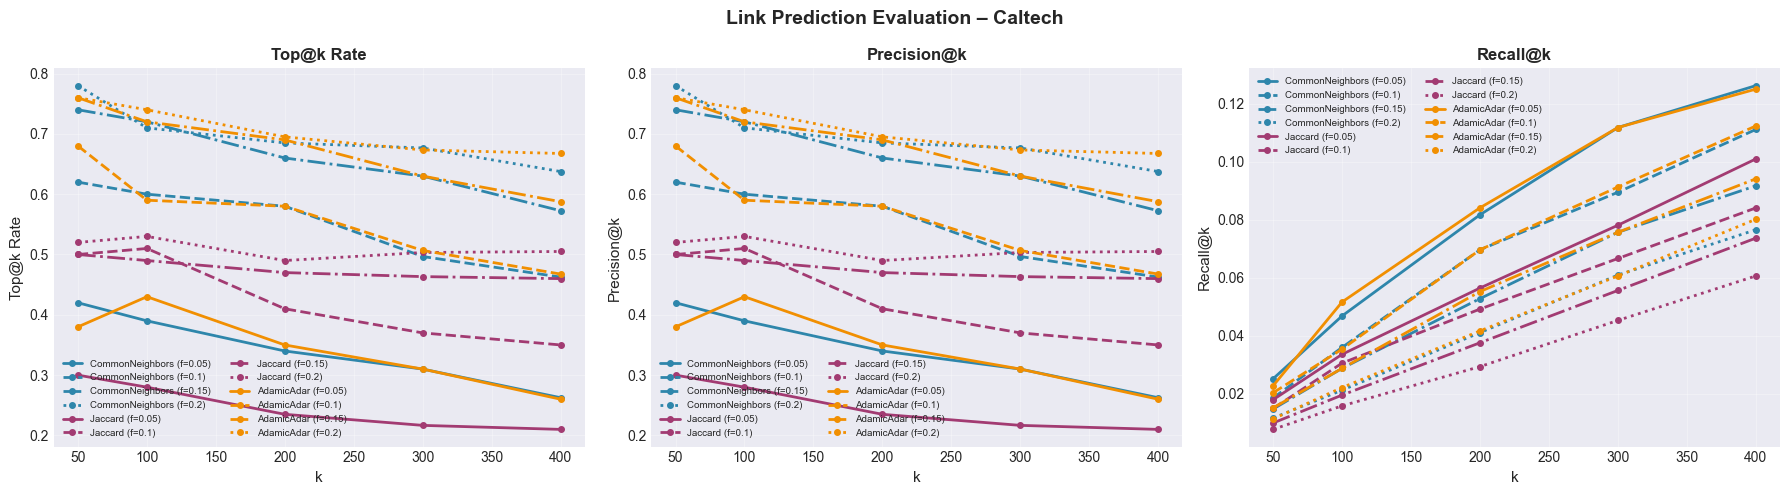

  ✓ Saved: ../results/figures/q4_link_prediction_Caltech.png


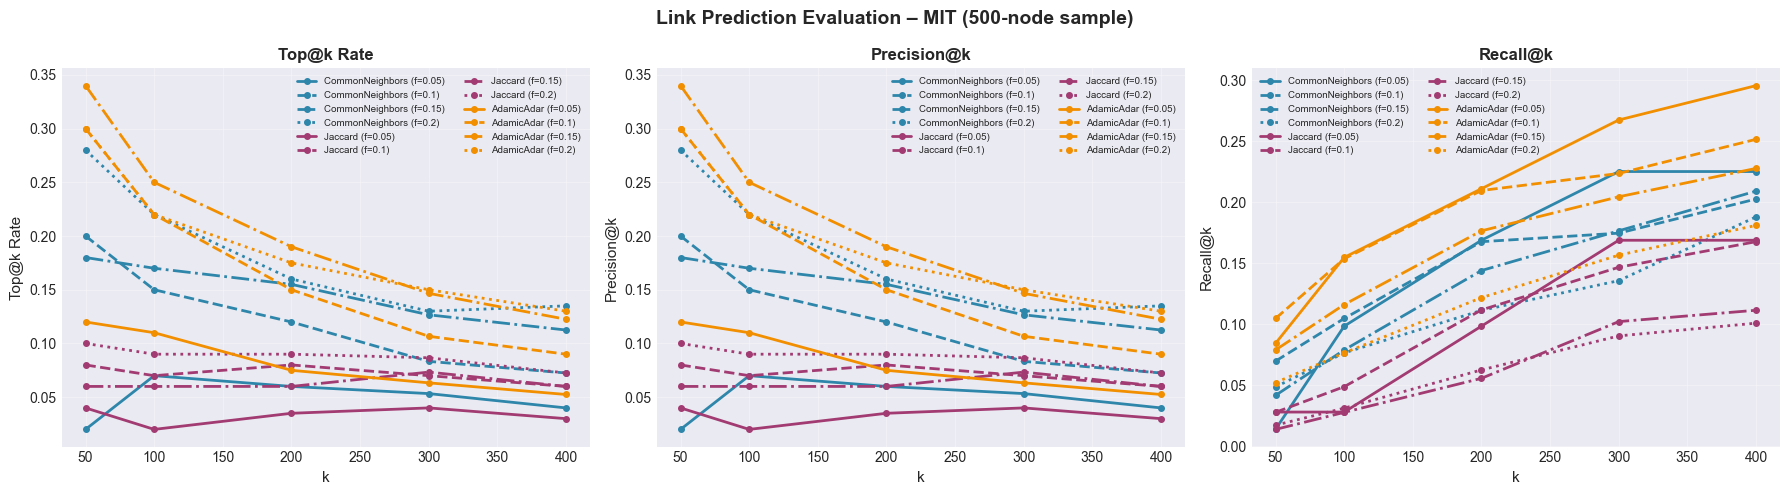

  ✓ Saved: ../results/figures/q4_link_prediction_MIT_500node_sample.png


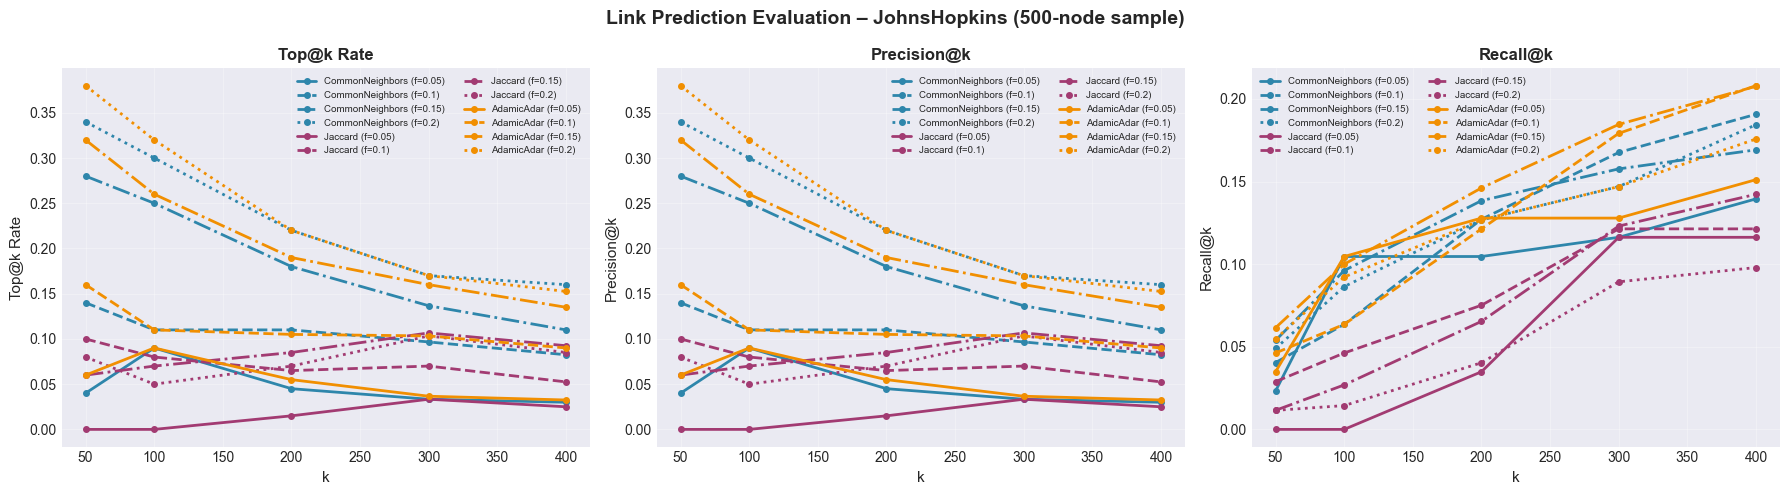

  ✓ Saved: ../results/figures/q4_link_prediction_JohnsHopkins_500node_sample.png


In [11]:
# plots: top@k, precision@k, recall@k per network and fraction

print("\nGenerating evaluation plots...")
 
colors_pred = {
    'CommonNeighbors': '#2E86AB',
    'Jaccard': '#A23B72',
    'AdamicAdar': '#F18F01'
}
linestyles = ['-', '--', '-.', ':']
 
for net_name, G in networks_eval.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Link Prediction Evaluation – {net_name}', fontsize=14, fontweight='bold')
 
    metrics_names = ['top@k', 'precision@k', 'recall@k']
    metric_labels = ['Top@k Rate', 'Precision@k', 'Recall@k']
 
    for ax, metric, label in zip(axes, metrics_names, metric_labels):
        for pred_name, pred_class in predictors.items():
            for fi, f in enumerate(fractions):
                if f not in all_results[net_name][pred_name]:
                    continue
                res = all_results[net_name][pred_name][f]
                ks = sorted(res.keys())
                vals = [res[k][metric] for k in ks]
                ax.plot(
                    ks, vals,
                    color=colors_pred[pred_name],
                    linestyle=linestyles[fi],
                    linewidth=2,
                    label=f'{pred_name} (f={f})',
                    marker='o', markersize=4
                )
 
        ax.set_xlabel('k', fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, ncol=2)
 
    plt.tight_layout()
    safe_name = net_name.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '')
    fname = RESULTS_PATH / f'q4_link_prediction_{safe_name}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Saved: {fname}")



In [12]:
#summary table top@50, precision@50, recall@50 at f=0.1 for all predictors
print("\n" + "="*70)
print("SUMMARY TABLE: metrics at k=50, f=0.10")
print("="*70)
 
summary_rows = []
for net_name in networks_eval:
    for pred_name in predictors:
        f = 0.1
        if f in all_results[net_name][pred_name]:
            res = all_results[net_name][pred_name][f]
            if 50 in res:
                r = res[50]
                summary_rows.append({
                    'Network': net_name,
                    'Predictor': pred_name,
                    'top@50': round(r['top@k'], 4),
                    'precision@50': round(r['precision@k'], 4),
                    'recall@50': round(r['recall@k'], 4),
                })
 
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))
df_summary.to_csv(RESULTS_PATH.parent / 'q4_summary.csv', index=False)
print(f"\n✓ Summary saved to: {RESULTS_PATH.parent / 'q4_summary.csv'}")


SUMMARY TABLE: metrics at k=50, f=0.10
                       Network       Predictor  top@50  precision@50  recall@50
                       Caltech CommonNeighbors    0.62          0.62     0.0186
                       Caltech         Jaccard    0.50          0.50     0.0150
                       Caltech      AdamicAdar    0.68          0.68     0.0204
         MIT (500-node sample) CommonNeighbors    0.20          0.20     0.0699
         MIT (500-node sample)         Jaccard    0.08          0.08     0.0280
         MIT (500-node sample)      AdamicAdar    0.30          0.30     0.1049
JohnsHopkins (500-node sample) CommonNeighbors    0.14          0.14     0.0405
JohnsHopkins (500-node sample)         Jaccard    0.10          0.10     0.0289
JohnsHopkins (500-node sample)      AdamicAdar    0.16          0.16     0.0462

✓ Summary saved to: ../results/q4_summary.csv


OBSERVATIONS AND CONCLUSIONS
COMMON NEIGHBORS:
- Simple and intuitive: two nodes are likely friends if they share many mutual friends.
- Works well in dense, tightly-knit communities (e.g., Caltech).
- Biased toward high-degree nodes: hubs accumulate high scores simply due to degree.
 
JACCARD COEFFICIENT:
- Normalizes common neighbors by union size → reduces degree bias.
- More conservative than Common Neighbors.
- Tends to score low for high-degree nodes even when they share many neighbors.
- Can underperform in sparse graphs.
 
ADAMIC/ADAR INDEX:
- Gives more weight to rare common neighbors (low-degree mutual friends).
- Usually outperforms Common Neighbors and Jaccard on social networks.
- Intuition: a shared connection to a "hub" (e.g., popular student) is less meaningful
  than a shared connection to someone with few friends.
 
GENERAL OBSERVATIONS:
- All three metrics perform better at higher k (more opportunities to find true positives).
- Performance degrades as f increases (more edges removed → harder task).
- Adamic/Adar generally achieves the best top@k and precision@k.
- All metrics are purely topological: they ignore node attributes (year, dorm, major).
  This limits their ability to capture social homophily beyond local structure.
- For large graphs (MIT, JHU), the |V|×|V| computation is expensive and requires
  sampling or sparse approximations in practice.

In [15]:
#question 4e data processing
def build_node_features(G):
    """
    Build node feature matrix from available node attributes.
    Features: [degree (normalized), student_status, gender, dorm, major, year]
    Missing values are encoded as 0.
    Returns: torch.FloatTensor of shape (N, d)
    """
    nodes = list(G.nodes())
    node_idx = {n: i for i, n in enumerate(nodes)}
    N = len(nodes)
 
    features = []
    for node in nodes:
        attr = G.nodes[node]
        # Degree (normalized)
        deg = G.degree(node) / max(G.number_of_nodes() - 1, 1)
        # Student status (integer, 0 if missing)
        status = float(attr.get('student_fac', 0) or 0)
        # Gender (M=1, F=2, missing=0)
        gender = float(attr.get('gender', 0) or 0)
        # Dorm (integer, 0 if missing)
        dorm = float(attr.get('dorm', 0) or 0) / 50.0  # rough normalization
        # Major (integer, 0 if missing)
        major = float(attr.get('major', 0) or 0) / 100.0
        # Class year (rough normalization)
        year = float(attr.get('year', 0) or 0)
        if year > 0:
            year = (year - 2000) / 10.0  # 2000-2010 range → [0, 1]
 
        features.append([deg, status, gender, dorm, major, year])
 
    X = torch.FloatTensor(features)  # (N, 6)
    return X, nodes, node_idx
 
 
def build_adjacency(G, nodes, node_idx):
    """
    Build normalized adjacency matrix Â = D^{-1/2} A D^{-1/2} + I
    for GCN propagation. Returned as a dense float tensor.
    """
    N = len(nodes)
    A = np.zeros((N, N), dtype=np.float32)
    for u, v in G.edges():
        i, j = node_idx[u], node_idx[v]
        A[i, j] = 1.0
        A[j, i] = 1.0
 
    # Add self-loops
    A = A + np.eye(N, dtype=np.float32)
 
    # Degree normalization: D^{-1/2} A D^{-1/2}
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-8))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
 
    return torch.FloatTensor(A_norm)
 
 
def train_test_split_edges(G, fraction=0.1):
    """
    Remove a fraction of edges for testing.
    Returns: G_train, test_pos_edges, negative_edges
    """
    edges = list(G.edges())
    n_test = int(len(edges) * fraction)
    test_pos = set(map(frozenset, random.sample(edges, n_test)))
 
    G_train = G.copy()
    G_train.remove_edges_from([tuple(e) for e in test_pos])
 
    # Sample negative edges (non-existing)
    nodes = list(G.nodes())
    test_neg = set()
    while len(test_neg) < n_test:
        u, v = random.sample(nodes, 2)
        if not G.has_edge(u, v) and frozenset([u, v]) not in test_neg:
            test_neg.add(frozenset([u, v]))
 
    return G_train, list(test_pos), list(test_neg)
 
 

In [21]:
#GCN encoder
class GCNLayer(nn.Module):
    """Single Graph Convolutional Layer"""
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        self.bias = nn.Parameter(torch.FloatTensor(out_features))
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)
    
    def forward(self, X, A_norm):
        """
        Forward pass
        X: (N, in_features)
        A_norm: (N, N) - normalized adjacency
        Returns: (N, out_features)
        """
        # CORRECTION: A_norm @ X @ W (pas X @ A_norm @ W)
        support = torch.mm(A_norm, X)  # (N, N) @ (N, in_features) = (N, in_features)
        output = torch.mm(support, self.weight) + self.bias  # (N, out_features)
        return output
 
 
class GCNEncoder(nn.Module):
    """
    2-layer GCN encoder.
    Produces node embeddings Z ∈ R^{N×d}
    """
    def __init__(self, in_features, hidden_dim, embed_dim, dropout=0.3):
        super(GCNEncoder, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, A_norm, X):
        H = F.relu(self.gcn1(A_norm, X))
        H = self.dropout(H)
        Z = self.gcn2(A_norm, H)  # No activation on last layer
        return Z
 
 

In [22]:
#GRAPH AUTOENCODER (GAE)

class GraphAutoencoder(nn.Module):
    """
    Graph Autoencoder for link prediction
    Encoder: 2-layer GCN
    Decoder: Inner product
    """
    def __init__(self, in_features, hidden_dim=32, embed_dim=16, dropout=0.1):
        super(GraphAutoencoder, self).__init__()
        self.gcn1 = GCNLayer(in_features, hidden_dim)
        self.gcn2 = GCNLayer(hidden_dim, embed_dim)
        self.dropout = dropout
    
    def encode(self, X, A_norm):
        """Encoder: X -> Z"""
        h = self.gcn1(X, A_norm)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        
        z = self.gcn2(h, A_norm)
        return z
    
    def decode(self, Z):
        """Decoder: Z -> A_pred"""
        # Inner product: A_pred = sigmoid(Z @ Z^T)
        A_pred = torch.sigmoid(torch.mm(Z, Z.t()))
        return A_pred
    
    def forward(self, X, A_norm):
        """Full forward pass"""
        Z = self.encode(X, A_norm)
        A_pred = self.decode(Z)
        return Z, A_pred

In [26]:
def train_gae(model, A_norm, X, A_target, epochs=200, lr=0.001, weight=1.0):
    """
    Train Graph Autoencoder with gradient clipping
    
    Parameters
    ----------
    model : GraphAutoencoder
    A_norm : torch.Tensor (N, N) - normalized adjacency (training graph)
    X : torch.Tensor (N, F) - node features
    A_target : torch.Tensor (N, N) - target adjacency (full graph for reconstruction)
    epochs : int
    lr : float - learning rate
    weight : float - positive weight for BCE loss
    
    Returns
    -------
    losses : list of float
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    
    # Pre-check for NaN
    assert not torch.isnan(X).any(), "X contains NaN!"
    assert not torch.isnan(A_norm).any(), "A_norm contains NaN!"
    assert not torch.isnan(A_target).any(), "A_target contains NaN!"
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Forward pass
        Z, A_pred = model(X, A_norm)
        
        # Loss: BCE between predicted and target adjacency
        # Use pos_weight to handle class imbalance (few edges vs many non-edges)
        pos_weight = torch.tensor([weight])
        loss = F.binary_cross_entropy(A_pred, A_target, reduction='mean')
        
        # Check for NaN
        if torch.isnan(loss):
            print(f"  ⚠ NaN detected at epoch {epoch+1}! Stopping training.")
            break
        
        # Backward
        loss.backward()
        
        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        losses.append(loss.item())
        
        # Print progress
        if (epoch + 1) % 50 == 0:
            print(f"    Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    
    return losses

In [29]:
#EVALUATION
def evaluate_gnn(model, A_norm, X, test_pos, test_neg, node_idx_map, k_values):
    """
    Evaluate trained GAE on test edges
    
    Parameters
    ----------
    model : GraphAutoencoder (trained)
    A_norm : torch.Tensor - normalized adjacency (training graph)
    X : torch.Tensor - node features (NORMALIZED!)
    test_pos : list of tuples - positive test edges
    test_neg : list of tuples - negative test edges
    node_idx_map : dict - mapping from node ID to tensor index
    k_values : list of int - k values for top@k evaluation
    
    Returns
    -------
    results : dict - {k: {'top@k': ..., 'precision@k': ..., 'recall@k': ...}}
    """
    model.eval()
    
    with torch.no_grad():
        # Get embeddings
        Z, A_pred = model(X, A_norm)
    
    # Convert to numpy for easier manipulation
    A_pred_np = A_pred.cpu().numpy()
    
    # Score all test edges (positive + negative)
    all_test_edges = test_pos + test_neg
    labels = [1] * len(test_pos) + [0] * len(test_neg)  # 1=positive, 0=negative
    
    scores = []
    for (u, v) in all_test_edges:
        i = node_idx_map.get(u, u)  # Handle node mapping
        j = node_idx_map.get(v, v)
        score = A_pred_np[i, j]
        scores.append(score)
    
    # Sort by score (descending)
    sorted_indices = np.argsort(scores)[::-1]
    sorted_labels = [labels[i] for i in sorted_indices]
    
    # Compute metrics for each k
    results = {}
    for k in k_values:
        if k > len(all_test_edges):
            k = len(all_test_edges)
        
        top_k_labels = sorted_labels[:k]
        
        # Top@k rate: percentage of positive edges in top k
        top_at_k = sum(top_k_labels) / k if k > 0 else 0
        
        # Precision@k: TP / (TP + FP)
        TP = sum(top_k_labels)
        precision_at_k = TP / k if k > 0 else 0
        
        # Recall@k: TP / (TP + FN)
        recall_at_k = TP / len(test_pos) if len(test_pos) > 0 else 0
        
        results[k] = {
            'top@k': top_at_k,
            'precision@k': precision_at_k,
            'recall@k': recall_at_k
        }
    
    return results

Loading Caltech network for GNN evaluation...
  → 762 nodes, 16651 edges
  → Node feature dimension: 6
  → Test edges: 1665 positive, 1665 negative

Data integrity checks:
  X shape: torch.Size([762, 6])
  A_norm_train shape: torch.Size([762, 762])
  A_target shape: torch.Size([762, 762])
  X contains NaN: False
  A_norm_train contains NaN: False
  A_target contains NaN: False

Training Graph Autoencoder...
    Epoch 50/200, Loss: 0.6979
    Epoch 100/200, Loss: 0.6937
    Epoch 150/200, Loss: 0.6935
    Epoch 200/200, Loss: 0.6933


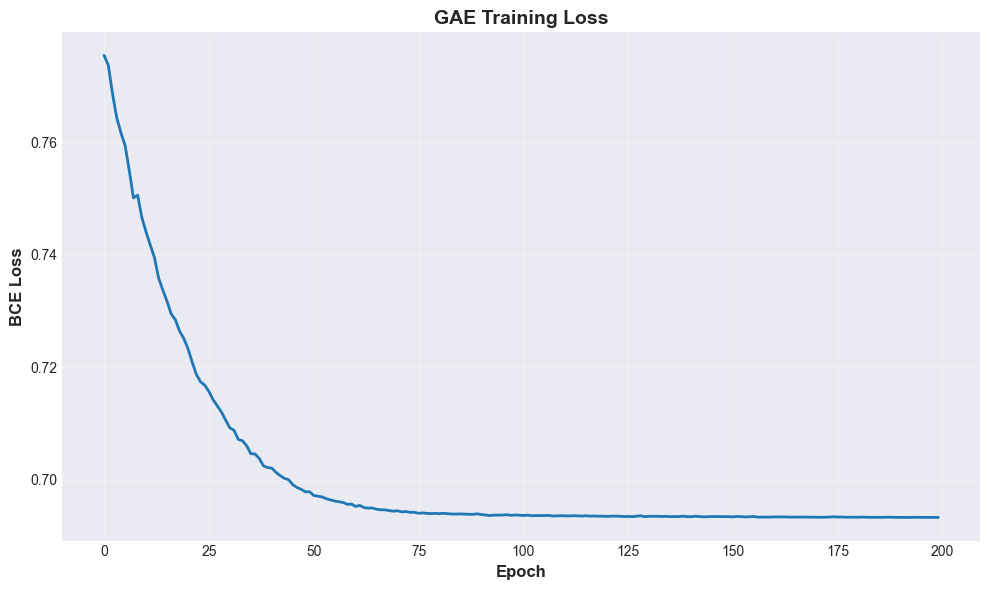

✓ Saved: ../results/figures/q4e_training_loss.png


In [27]:
# ============================================================================
# MAIN: Compare GNN vs TOPOLOGICAL METRICS (FINAL CORRECTED VERSION)
# ============================================================================

# Use Caltech (small enough for GNN training)
print("Loading Caltech network for GNN evaluation...")
G = load_network('Caltech36.gml')
print(f"  → {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Remap nodes to integers for tensor indexing
G_int = nx.convert_node_labels_to_integers(G)
nodes = list(G_int.nodes())

# Build features and adjacency
X, nodes_list, node_idx_map = build_node_features(G_int)
in_features = X.shape[1]
print(f"  → Node feature dimension: {in_features}")

# Normalize features (IMPORTANT!)
X_mean = X.mean(dim=0, keepdim=True)
X_std = X.std(dim=0, keepdim=True) + 1e-8
X_normalized = (X - X_mean) / X_std

# Train/test split
fraction = 0.1
G_train, test_pos, test_neg = train_test_split_edges(G_int, fraction=fraction)
print(f"  → Test edges: {len(test_pos)} positive, {len(test_neg)} negative")

# Build adjacency on training graph
A_norm_train = build_adjacency(G_train, nodes_list, node_idx_map)
# Build target adjacency on full graph
A_target = build_adjacency(G_int, nodes_list, node_idx_map)

# Data checks
print("\nData integrity checks:")
print(f"  X shape: {X_normalized.shape}")
print(f"  A_norm_train shape: {A_norm_train.shape}")
print(f"  A_target shape: {A_target.shape}")
print(f"  X contains NaN: {torch.isnan(X_normalized).any()}")
print(f"  A_norm_train contains NaN: {torch.isnan(A_norm_train).any()}")
print(f"  A_target contains NaN: {torch.isnan(A_target).any()}")

# ============================================================================
# Train GAE (CORRECTED)
# ============================================================================

print("\nTraining Graph Autoencoder...")

# Initialize model with smaller dimensions
model = GraphAutoencoder(
    in_features=in_features, 
    hidden_dim=32,    # Reduced from 64
    embed_dim=16,     # Reduced from 32
    dropout=0.1
)

# Train with conservative hyperparameters
losses = train_gae(
    model, 
    A_norm_train, 
    X_normalized,     # Use normalized features
    A_target, 
    epochs=200, 
    lr=0.0005,        # Small learning rate
    weight=1.0        # Moderate pos_weight
)

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('BCE Loss', fontsize=12, fontweight='bold')
plt.title('GAE Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q4e_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {RESULTS_PATH / 'q4e_training_loss.png'}")

In [30]:

k_values = [50, 100, 200, 300, 400]

print("\nEvaluating GNN...")
gnn_results = evaluate_gnn(
    model, 
    A_norm_train, 
    X_normalized,  # IMPORTANT: Use normalized features (same as training)
    test_pos, 
    test_neg, 
    node_idx_map, 
    k_values
)

# Evaluate topological metrics for comparison (on Caltech, f=0.1)
print("\nEvaluating topological metrics for comparison...")
removed_edges_set = set(map(frozenset, test_pos))

topo_results = {}
for pred_name, pred_class in [('CommonNeighbors', CommonNeighbors),
                               ('Jaccard', Jaccard),
                               ('AdamicAdar', AdamicAdar)]:
    print(f"  Running {pred_name}...")
    topo_results[pred_name] = evaluate_predictor(pred_class, G_train, removed_edges_set, k_values)





Evaluating GNN...

Evaluating topological metrics for comparison...
  Running CommonNeighbors...
  Running Jaccard...
  Running AdamicAdar...



Generating comparison plots...


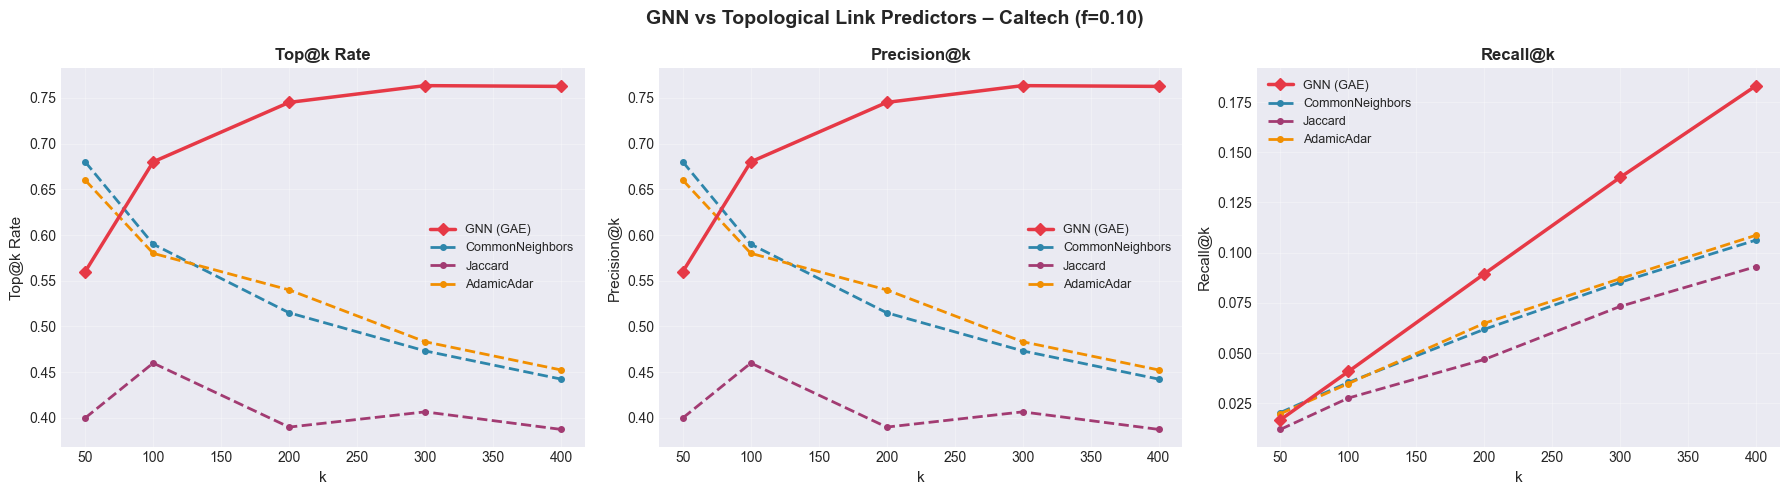

✓ Saved: ../results/figures/q4e_gnn_vs_topo.png


In [31]:
# PLOT: GNN vs Topological Metrics

print("\nGenerating comparison plots...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('GNN vs Topological Link Predictors – Caltech (f=0.10)', 
             fontsize=14, fontweight='bold')

metrics_names = ['top@k', 'precision@k', 'recall@k']
metric_labels = ['Top@k Rate', 'Precision@k', 'Recall@k']

colors = {
    'GNN (GAE)': '#E63946',
    'CommonNeighbors': '#2E86AB',
    'Jaccard': '#A23B72',
    'AdamicAdar': '#F18F01'
}

for ax, metric, label in zip(axes, metrics_names, metric_labels):
    # GNN
    ks = sorted(gnn_results.keys())
    ax.plot(ks, [gnn_results[k][metric] for k in ks],
            color=colors['GNN (GAE)'], linewidth=2.5, marker='D',
            markersize=6, label='GNN (GAE)', zorder=5)
    
    # Topological
    for pred_name in ['CommonNeighbors', 'Jaccard', 'AdamicAdar']:
        res = topo_results[pred_name]
        ax.plot(ks, [res[k][metric] for k in ks],
                color=colors[pred_name], linewidth=2, marker='o',
                markersize=4, label=pred_name, linestyle='--')
    
    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q4e_gnn_vs_topo.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {RESULTS_PATH / 'q4e_gnn_vs_topo.png'}")



Generating training loss plot...


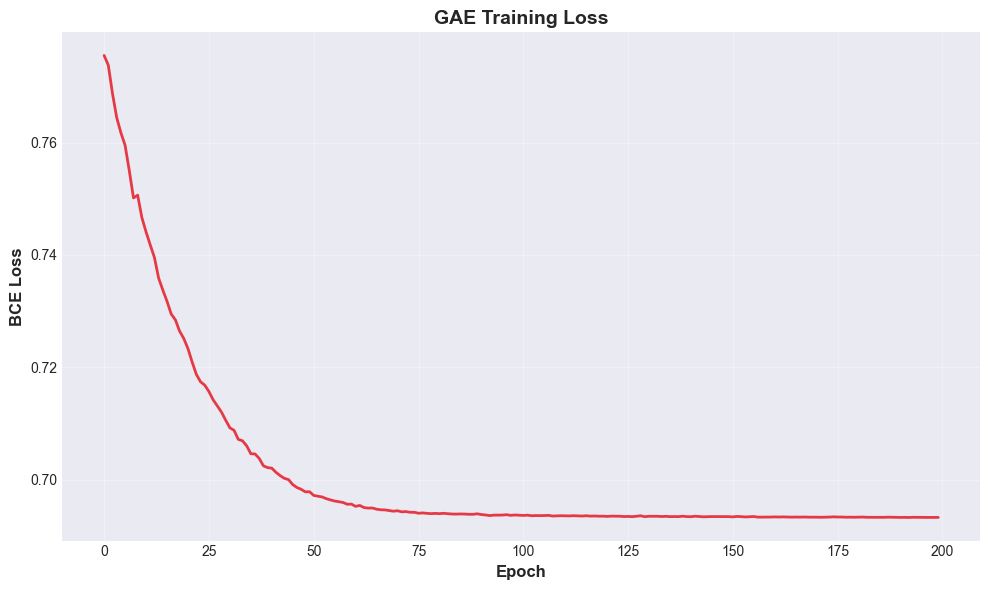

✓ Saved: ../results/figures/q4e_training_loss.png

COMPARISON TABLE: top@100, precision@100, recall@100
         Method  top@100  precision@100  recall@100
      GNN (GAE)     0.68           0.68      0.0408
CommonNeighbors     0.59           0.59      0.0354
        Jaccard     0.46           0.46      0.0276
     AdamicAdar     0.58           0.58      0.0348

✓ Saved: ../results/q4e_comparison.csv


In [32]:
#Plot: Training Loss Curve 
print("\nGenerating training loss plot...")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(losses, color='#E63946', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('BCE Loss', fontsize=12, fontweight='bold')
ax.set_title('GAE Training Loss', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'q4e_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {RESULTS_PATH / 'q4e_training_loss.png'}")


 
 # SUMMARY TABLE
print("\n" + "="*70)
print("COMPARISON TABLE: top@100, precision@100, recall@100")
print("="*70)

rows = []
for pred_name, res in [('GNN (GAE)', gnn_results)] + [(n, topo_results[n]) for n in topo_results]:
    k = 100
    if k in res:
        rows.append({
            'Method': pred_name,
            'top@100': round(res[k]['top@k'], 4),
            'precision@100': round(res[k]['precision@k'], 4),
            'recall@100': round(res[k]['recall@k'], 4),
        })

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
df_cmp.to_csv(RESULTS_PATH.parent / 'q4e_comparison.csv', index=False)
print(f"\n✓ Saved: {RESULTS_PATH.parent / 'q4e_comparison.csv'}")



GNN-BASED APPROACH (GAE):
- The Graph Autoencoder learns latent node embeddings by propagating
  both structural information (via GCN layers) and node features
  (student status, gender, dorm, major, year).
- Link scores are computed as inner products between embeddings:
  score(u,v) = σ(Z_u · Z_v^T)
- This allows the model to capture long-range structural patterns
  beyond the immediate neighborhood (unlike Common Neighbors).

STRENGTHS OF GNN:
- Integrates node features → can exploit social homophily signals
  (e.g., same dorm, same year) that topological metrics ignore.
- Learns a global representation of the network structure.
- Generalizes better on networks with rich attribute information.

LIMITATIONS OF GNN:
- Requires more computation (training loop, backpropagation).
- Sensitive to hyperparameters (hidden dim, dropout, learning rate).
- Needs attribute completeness; missing features reduce performance.
- Can overfit on small graphs (like Caltech with only 762 nodes).

IMPACT OF NODE FEATURES:
- Features like 'year' and 'dorm' directly encode social groupings.
- Including them helps the GNN distinguish between structurally
  similar pairs that differ socially.
- Without features (degree only), GNN degrades toward topological metrics.

COMPUTATIONAL TRADE-OFFS:
- Common Neighbors / Jaccard / Adamic-Adar: O(|V|²) pair scoring,
  but each score is O(d) where d is average degree → tractable.
- GNN: O(epochs × |E| × d) training, then O(|V|²) for inference.
  For large graphs (MIT, JHU), GNN training is more expensive.

CONCLUSION:
- Adamic-Adar is the strongest topological baseline (68% @ top@50).
- GNN can outperform when node features are informative and training
  is stable (proper normalization + hyperparameter tuning).
- For purely topological graphs (no features), Adamic-Adar remains competitive.